# Parametric Cranberry Product: Empirical Data Validation

In [16]:
from datetime import date
import meteostat as ms
import pandas as pd
df = pd.read_parquet("data/wisconsin_rapids_daily.parquet")

To start this exploration, we pull temperature data from the Wisconsin Rapids Weather Station. Pick a lat/long point, pull data from nearby stations, and interpolate that data to the lat/long point.

In [17]:
# Wisconsin Rapids Station

#POINT = ms.Point(44.36, -89.84, 311) # lat, long, elevation (m)
#start = date(1995, 1, 1)
#end = date(2024, 12, 31)

# Find nearby stations and pull daily data
#stations = ms.stations.nearby(POINT, limit=4)
#ts = ms.daily(stations, start, end)

# Interpolate from the stations to point
#df = ms.interpolate(ts,POINT).fetch()

#df.to_parquet("data/wisconsin_rapids_daily.parquet")

**Data Wrangling** <br>
Here we look at properties of our data frame, as well as converting temperatures into Fahrenheit.

In [18]:
df.head()

,temp,tmin,tmax,rhum,prcp,wspd,pres,cldc
time,,,,,,,,
2006-01-01,-0.3,-1.7,1.1,86,<NA>,12.8,1011.4,7
2006-01-02,1.6,1.1,2.2,90,<NA>,18.4,1010.0,8
2006-01-03,1.0,0.6,1.7,94,0.3,6.6,1012.9,8
2006-01-04,0.9,0.6,1.7,94,<NA>,11.0,1009.1,8
2006-01-05,-1.3,-2.8,0.6,77,0.0,17.2,1019.9,8


In [19]:
df.shape

(6940, 8)

In [20]:
df.dtypes

temp    Float64
tmin    Float64
tmax    Float64
rhum      UInt8
prcp    Float64
wspd    Float64
pres    Float64
cldc      UInt8
dtype: object

In [21]:
df.isna().sum()

temp       0
tmin      18
tmax      18
rhum       0
prcp    2396
wspd       0
pres       6
cldc    2359
dtype: int64

In [22]:
df["tmin_f"] = df["tmin"]*9/5 + 32
df["tmax_f"] = df["tmax"]*9/5 + 32
df["tavg_f"] = df["temp"]*9/5 + 32

In [23]:
df.head()

,temp,tmin,tmax,rhum,prcp,wspd,pres,cldc,tmin_f,tmax_f,tavg_f
time,,,,,,,,,,,
2006-01-01,-0.3,-1.7,1.1,86,<NA>,12.8,1011.4,7,28.94,33.98,31.46
2006-01-02,1.6,1.1,2.2,90,<NA>,18.4,1010.0,8,33.98,35.96,34.88
2006-01-03,1.0,0.6,1.7,94,0.3,6.6,1012.9,8,33.08,35.06,33.8
2006-01-04,0.9,0.6,1.7,94,<NA>,11.0,1009.1,8,33.08,35.06,33.62
2006-01-05,-1.3,-2.8,0.6,77,0.0,17.2,1019.9,8,26.96,33.08,29.66


Below we plot our daily minimum temperature for an entire year for 2023 to visualize our data.

<function matplotlib.pyplot.show(close=None, block=None)>

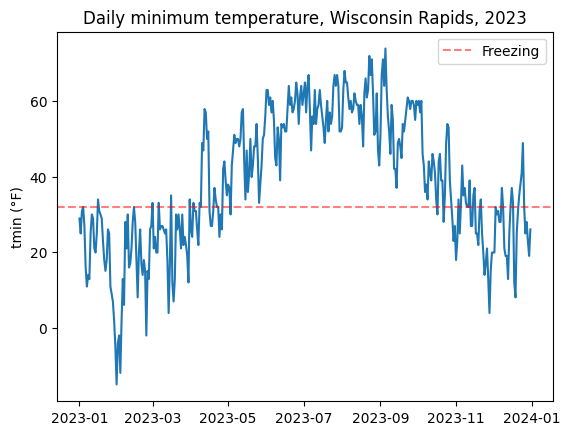

In [24]:
import matplotlib.pyplot as plt

df_2023 = df.loc["2023"]

plt.figure()
plt.plot(df_2023.index,df_2023["tmin_f"])
plt.axhline(32, color = "red", linestyle = "--", alpha = 0.5, label = "Freezing")
plt.title("Daily minimum temperature, Wisconsin Rapids, 2023")
plt.ylabel("tmin (°F)")
plt.legend()
plt.show

In the context of cranberry frost, our window of importance is late spring. In the wintertime or spring months with significant frequency of daily lows below freezing, plants are dormant. In the summer, daily lows below the critical frost threshold are unrealistic. The transitional period of May and June, when bud growth is occuring, provides the most vulnerable window for frost damage. <br>
<br>
Below we restrict our window of interest to data from May and June, graphing daily minimum temperatures over all years.

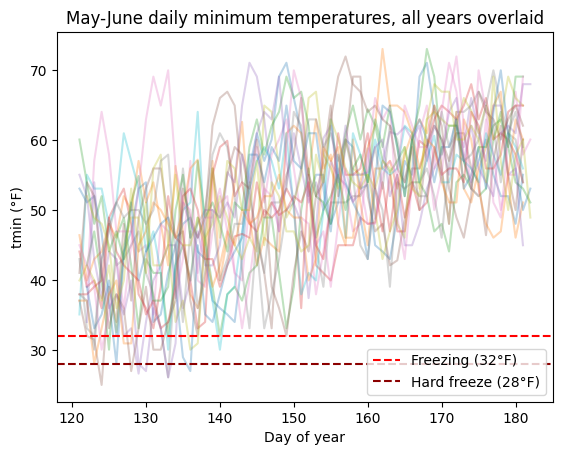

In [25]:
spring = df[(df.index.month >= 5) & (df.index.month <= 6)].copy()
spring["year"] = spring.index.year
spring["day_of_year"] = spring.index.dayofyear

for year, grp in spring.groupby("year"):
    plt.plot(grp["day_of_year"], grp["tmin_f"], alpha = 0.3)

plt.axhline(32, color="red", linestyle="--", label="Freezing (32°F)")
plt.axhline(28, color="darkred", linestyle="--", label="Hard freeze (28°F)")
plt.title("May-June daily minimum temperatures, all years overlaid")
plt.xlabel("Day of year")
plt.ylabel("tmin (°F)")
plt.legend()
plt.show()

Visually, we can identify a few instances where daily minimum temperatures dropped below thresholds of freezing and hard freeze. These thredsholds are good starting points; however, different critical thresholds apply at different stages of the plant growth cycle. Below is an exploration of temporal stage-adjusted thresholds.

In [26]:
def critical_temp(doy):
    if doy < 121: return None # Before May 1
    if doy <= 138: return 25 # late dormant / bud swelling (May 1-18, hardiest)
    if doy <= 151: return 26 # Cabbagehead / hook (May 19-31)
    if doy <= 165: return 27 # Rough-neck (June 1-14)
    if doy <= 181: return 30 # Bloom / fruit set (June 15-30, most vulnerable to loss)
spring["doy"] = spring.index.dayofyear
spring["threshold"] = spring["doy"].apply(critical_temp)
spring["frost"] = spring["tmin_f"] < spring["threshold"]


years_with_frost = spring[spring["frost"]]["year"].nunique()
total_years = spring["year"].nunique()

print(f"{years_with_frost} of {total_years} years had at least one daily minimum temperature less than the stage-adjusted threshold.")
print(f"Empiriral frequency: {years_with_frost/ total_years:.1%}")

1 of 19 years had at least one daily minimum temperature less than the stage-adjusted threshold.
Empiriral frequency: 5.3%


Two important notes here: <br>
1) True stage-adjusted thresholds are dependent on stage of plant development, which is difficult to capture in a uniform way. A calendar mesh does a decent job for initial exploration, but doesn't encapsulate perturbations in growing season dates year over year. A more accurate inference of bud development stage is growing degree-day accumulation. **This will be built out later**
2) Daily minimum temperature at the bog level is oftentimes lower than the daily minimum temperature at weather stations. This adjustment will have to be made, as pure interpolation from weather stations will give an inaccurate view of frost-risk on location. **This will be built out later**

In [27]:
print(spring.groupby("year")["tmin_f"].min().sort_values().head(15))


year
2011    24.98
2013    26.06
2020    26.06
2010     26.6
2016    26.96
2021    26.96
2017    28.04
2006    28.04
2014    30.02
2015    30.02
2008    30.02
2022    30.02
2023    30.02
2009    33.08
2019    33.08
Name: tmin_f, dtype: Float64


In [28]:
print(spring["threshold"].value_counts(dropna=False))

threshold
25.0    337
30.0    304
27.0    266
26.0    247
NaN       5
Name: count, dtype: int64


In [29]:
# Closest calls — how far did tmin get from threshold each year?
spring["margin"] = spring["tmin_f"] - spring["threshold"]
print(spring.groupby("year")["margin"].min().sort_values().head(15))

year
2011   -0.02
2013    1.06
2020    1.06
2010     1.6
2016    1.96
2021    1.96
2017    3.04
2006    3.04
2015    4.02
2014    5.02
2008    5.02
2022    5.02
2023    5.02
2009    8.08
2019    8.08
Name: margin, dtype: Float64


Exploring the specific dates on which the lowest daily minimum temperature in each year's May/June window occured.

In [30]:
closest_calls = spring.loc[spring.groupby("year")["margin"].idxmin()][["year", "tmin_f", "threshold", "margin"]].sort_values("margin")
print(closest_calls.head(15))

            year  tmin_f  threshold  margin
time                                       
2011-05-04  2011   24.98       25.0   -0.02
2013-05-13  2013   26.06       25.0    1.06
2020-05-12  2020   26.06       25.0    1.06
2010-05-09  2010    26.6       25.0     1.6
2016-05-15  2016   26.96       25.0    1.96
2021-05-08  2021   26.96       25.0    1.96
2017-05-03  2017   28.04       25.0    3.04
2006-05-06  2006   28.04       25.0    3.04
2015-05-20  2015   30.02       26.0    4.02
2014-05-16  2014   30.02       25.0    5.02
2008-05-04  2008   30.02       25.0    5.02
2022-05-04  2022   30.02       25.0    5.02
2023-05-03  2023   30.02       25.0    5.02
2009-05-11  2009   33.08       25.0    8.08
2019-05-12  2019   33.08       25.0    8.08


Here we see the dates of closest call are clustered around the first two weeks of May. Generally to be expected and correlates to our lowest threshold. The technical refinements as stated above are good next steps, but only when we know what we are refining based on. The actual next step is to compare these near-miss years to actual loss data. Looking for a drop in cranberry-yield data from USDA NASS, higher loss-ratio years from USDA RMA MPCI cranberry coverage in WI, and even newspaper articles on specific Wisconsin cranberry frost events, can all provide evidence on if these close calls truly have signal.

# Validation of Loss Ratio data

Below we load data on the USDA RMA MPCI cranberry coverage in Wood County (Wisconsin Rapids area).

In [31]:
lr = pd.read_excel("data/USDA RMA Cranberry LR Data - Wood County.xlsx", header = 1)
lr.columns = lr.columns.str.strip() # removes leading or trailing whitespace in USDA column names

# Filter to keep columns we care about only
lr = lr[["Commodity Year", "Policies Sold", "Policies Indemnified", "Total Prem ($)", "Indemnity ($)", "Loss Ratio"]].dropna(subset=["Commodity Year"])
lr = lr.rename(columns={"Commodity Year": "year"}).sort_values("year").reset_index(drop=True)

lr.head()
print(lr)

    year  Policies Sold  Policies Indemnified  Total Prem ($)  Indemnity ($)  \
0   1989             12                     8          141763        1066330   
1   1990             13                     2          133462         242044   
2   1991             13                     4          165666         423548   
3   1992             15                     3          179378         589001   
4   1993             17                     8          252048         471026   
5   1994             14                     2          312407         280572   
6   1995             33                     4          591952         214678   
7   1996             30                     2          537187         103402   
8   1997             33                     2          634071         135858   
9   1998             37                     1          753539          35367   
10  1999             37                     0          643042              0   
11  2000             39                 

In [32]:
validation = closest_calls.merge(lr, on = "year", how = "left").sort_values("margin")
validation

,year,tmin_f,threshold,margin,Policies Sold,Policies Indemnified,Total Prem ($),Indemnity ($),Loss Ratio
0,2011,24.98,25.0,-0.02,63,5,574100,144189,0.251156
1,2013,26.06,25.0,1.06,67,4,902521,141660,0.156960
2,2020,26.06,25.0,1.06,69,13,709195,848439,1.196340
3,2010,26.6,25.0,1.6,62,14,902841,1741300,1.928689
4,2016,26.96,25.0,1.96,65,3,810170,203096,0.250683
5,2021,26.96,25.0,1.96,68,31,790480,3834959,4.851430
6,2017,28.04,25.0,3.04,70,8,859846,826270,0.960951
7,2006,28.04,25.0,3.04,59,1,542688,8288,0.015272
8,2015,30.02,26.0,4.02,65,10,574586,626267,1.089944
9,2014,30.02,25.0,5.02,63,6,676978,219837,0.324732


When looking at the closest margins and the highest loss ratios, the temperature trigger shows a clear directional relationship between cold-spring-night margins and elevated loss ratios, with the largest single loss year (2021) coming within 2 dergees F of the trigger. <br>
<br>
https://www.jsonline.com/story/life/food/2021/11/19/cranberry-shortage-wisconsin-crop-yields-low-supply-fresh-fruit/8667610002/?gnt-cfr=1&gca-cat=p&gca-uir=true&gca-epti=z115326e1160xxv115326d--59--b--59--&gca-ft=187&gca-ds=sophi 
<br>
<br>
According to this article, the 2021 year (highest LR) experienced early warmth that caused premature blooming, followed by a hard frost in May that caused significant losses. This may be better predicted in the data if we use the approach of growing degree-day accumulation to determine stage or development, as this year likely would have had earlier GDD accumulation to bud-level, increasing the critical threshold at an earlier date, allowing for losses to come significantly easier. So that 26.96 degree minimum in 2021 was occuring at a much more developed stage than other years with a more vulnerable stage of plant development.

Where to pick up? Replicate this analysis for at least two other counties that grow cranberries

Random thoughts: From claude convo. This is the empirical piece. To prove. To price forward, price with uncertainty, the Mikosch book shows me the exact kinds of stochastic calculus I need. Weather is a mean- reversion process with a sinusoidal component (seasonal), linear component (climate warming), and a more random component (daily variation from mean). To price forward is to look at the PDF of this process, look at the frequency of predicted days below threshold (which threshold is also developed as a stochastic process). But this whole project also requires stochastic calculus. THey are not two separate ideas. This is the combination of insurance and hard math and agriculture. 

# Mutli-County Validation & Function Definitions

Defining data-pull function for efficiency

In [33]:
import os

# If I ever want to re-pull data, set force_refresh = true
def get_county_weather(name, point, start, end, force_refresh=False):
    path= f"data/{name}_daily.parquet"
    if os.path.exists(path) and not force_refresh:
        return pd.read_parquet(path)
    stations = ms.stations.nearby(point, limit = 4)
    ts = ms.daily(stations, start, end)
    df = ms.interpolate(ts, point).fetch()
    df.to_parquet(path)

In [34]:
# ONLY RUN THIS ONCE #

counties = {}
points = {}
points["wood"]=ms.Point(44.36, -89.84, 311)
points["jackson"]=ms.Point(44.296630,-90.726780, 273.71)
points["adams"]=ms.Point(43.965,-89.7925,276)
points["juneau"] = ms.Point(43.84,-90.14,276)

start = date(1995, 1, 1)
end = date(2024, 12, 31)

get_county_weather("wood", points["wood"], start, end)
get_county_weather("jackson", points["jackson"], start, end)
get_county_weather("adams", points["adams"], start, end)
get_county_weather("juneau", points["juneau"], start, end)

,temp,tmin,tmax,rhum,prcp,wspd,pres,cldc
time,,,,,,,,
1996-10-31,-2.7,<NA>,<NA>,60,<NA>,34.2,<NA>,3
1996-11-01,-3.1,-6.0,1.0,68,<NA>,27.2,1014.6,3
1996-11-02,-3.0,<NA>,<NA>,70,<NA>,20.8,1021.2,4
2005-03-29,13.8,<NA>,<NA>,46,<NA>,15.4,1003.0,7
2005-08-02,26.4,18.0,33.0,67,<NA>,8.0,1015.4,3
...,...,...,...,...,...,...,...,...
2024-12-27,3.2,1.9,5.7,98,13.3,12.0,1011.2,8
2024-12-28,3.1,0.7,6.1,93,1.8,15.2,1010.2,7
2024-12-29,1.2,-0.8,3.4,93,0.0,8.5,1010.4,8


Now I will build this out again for a new county. I will write a function to do so, so that going forward we can easily replicate data pulls for multiple counties.

In [35]:
# Define thresholds
def critical_temp(doy):
    if doy < 121: return None # Before May 1
    if doy <= 138: return 25 # late dormant / bud swelling (May 1-18, hardiest)
    if doy <= 151: return 26 # Cabbagehead / hook (May 19-31)
    if doy <= 165: return 27 # Rough-neck (June 1-14)
    if doy <= 181: return 30 # Bloom / fruit set (June 15-30, most vulnerable to loss)

def validate_county(station_point, lr_filepath, name):
    df = pd.read_parquet(f"data/{name}_daily.parquet")

    # Metric to F
    df["tmin_f"] = df["tmin"]*9/5 + 32
    df["tmax_f"] = df["tmax"]*9/5 + 32
    df["tavg_f"] = df["temp"]*9/5 + 32

    spring = df[(df.index.month >= 5) & (df.index.month <= 6)].copy()
    spring["year"] = spring.index.year    
    spring["doy"] = spring.index.dayofyear
    spring["threshold"] = spring["doy"].apply(critical_temp)
    spring["frost"] = spring["tmin_f"] < spring["threshold"]

    spring["margin"] = spring["tmin_f"] - spring["threshold"]
    closest_calls = spring.loc[spring.groupby("year")["margin"].idxmin()][["year", "tmin_f", "threshold", "margin"]].sort_values("margin")
    
    lr = pd.read_excel(lr_filepath, header = 1)
    lr.columns = lr.columns.str.strip() # removes leading or trailing whitespace in USDA column names

    # Filter to keep columns we care about only
    lr = lr[["Commodity Year", "Policies Sold", "Policies Indemnified", "Total Prem ($)", "Indemnity ($)", "Loss Ratio"]].dropna(subset=["Commodity Year"])
    lr = lr.rename(columns={"Commodity Year": "year"}).sort_values("year").reset_index(drop=True)

    # Merge threshold table with LR table
    validation = closest_calls.merge(lr, on = "year", how = "left").sort_values("margin")
    return validation


In [36]:
counties["wood"] = validate_county(points["wood"], "data/USDA RMA Cranberry LR Data - Wood County.xlsx", "wood")
counties["jackson"] = validate_county(points["jackson"], "data/USDA RMA Cranberry LR Data - Jackson County.xlsx", "jackson")



In [37]:
counties["jackson"]

,year,tmin_f,threshold,margin,Policies Sold,Policies Indemnified,Total Prem ($),Indemnity ($),Loss Ratio
0,2020,15.8,25.0,-9.2,39,7,219463,467577,2.130550
1,2021,19.58,25.0,-5.42,40,16,220907,1232911,5.581131
2,2016,20.3,25.0,-4.7,37,1,274622,205609,0.748698
3,2011,21.2,25.0,-3.8,36,2,262924,42783,0.162720
4,2013,22.46,25.0,-2.54,36,0,401293,0,0.000000
5,2023,23.54,25.0,-1.46,42,6,329313,264044,0.801802
6,2017,24.98,25.0,-0.02,38,3,269499,47944,0.177900
7,2022,25.16,25.0,0.16,42,12,314049,1616827,5.148327
8,2014,25.88,25.0,0.88,36,5,300420,129129,0.429828
9,2010,26.42,25.0,1.42,36,3,310070,106650,0.343954


In [38]:
counties["jackson"]["tmin_f"].describe()



count         19.0
mean     26.202105
std       4.979125
min           15.8
25%           23.0
50%          26.42
75%           29.3
max          35.42
Name: tmin_f, dtype: Float64

In [39]:
counties["wood"]["tmin_f"].describe()

count         19.0
mean     30.209474
std       3.788312
min          24.98
25%          26.96
50%          30.02
75%          33.08
max          37.04
Name: tmin_f, dtype: Float64

Replication in Jackson County shows a similar directional relationship between cold-spring-night margins and elevated loss ratios. Jackson county shows a higher trigger rate, which appears to reflect a colder local climate rather than a higher frost-risk profile, suggesting triggers may need county-level threshold calibration rather than single statewide values. Several years where the trigger fired had low LR - calendar-based threshold has substantial false-positive risk in colder counties. <br>
<br>
Note: Transitioning from calendar-based thresholds to GDD accumulation thresholds seems to be a good play to solve these issues. GDD accumulation is climate-dependent, so differences in growth development risks by county would be accounted for. <br>
<br> 
One more note: the severe 2021 event is even more pronounced here. Positive feedback to see that signal for the significant event in two counties.

Now looking at Adams county

In [40]:
counties["adams"] = validate_county(points["adams"], "data/USDA RMA Cranberry LR Data - Adams County.xlsx", "Adams")

In [41]:
counties["adams"]

,year,tmin_f,threshold,margin,Policies Sold,Policies Indemnified,Total Prem ($),Indemnity ($),Loss Ratio
0,2011,24.08,25.0,-0.92,9,2,111627,167382,1.499475
1,2016,24.08,25.0,-0.92,12,2,202088,30188,0.149380
2,2020,24.44,25.0,-0.56,11,2,146613,7035,0.047983
3,2021,24.62,25.0,-0.38,11,6,159631,870729,5.454636
4,2013,25.16,25.0,0.16,12,0,240228,0,0.000000
5,2014,26.24,25.0,1.24,13,3,183347,296913,1.619404
6,2010,26.42,25.0,1.42,8,3,143415,685655,4.780915
7,2017,27.5,25.0,2.5,11,1,185870,45147,0.242895
8,2022,27.5,25.0,2.5,10,3,201077,111241,0.553225
9,2006,28.04,25.0,3.04,10,1,88974,5570,0.062602


A few takeaways from the Adams county data:
- The 2021 event is still pronounced in this county, and the trigger pulls for Adams county.
- There are 5 years with LR > 1.5. 2014 and 2010 are near misses within 2 degrees of the trigger. 2023 can be ignored as an assumed non-frost loss event.
- Again, there are some misfires on triggers for low LR years. GDD accumulation instead of calendar years is my idea to fix this.
- 2010 in Adams county had a 4.78 LR for the near miss. Wood county also had a near miss, but elevated LR was only 1.93. Adams losses significantly worse than Wood's despite similar temperature signal. Adams growers may have been less protected, or frost penetrated bog temps more severely in Adams county than Wood
- 2014 in Adams had a LR of 1.62. Wood county had a 0.32 LR in the same year. Same weather data with totally different losses. Investigating this further is an interesting direction to go.
- 2011 in Adams triggered and had a LR of 1.50. In Wood county, 2011 triggered as a false positive with LR only 0.25. Same trigger, different outcome. This moves the basis risk from just "weather station vs. bog temps" to "same temperatures, different frost protection infrastructure in place by county." 


In [42]:
counties["juneau"] = validate_county(points["juneau"], "data/USDA RMA Cranberry LR Data - Juneau County.xlsx", "Juneau")

In [43]:
counties["juneau"]

,year,tmin_f,threshold,margin,Policies Sold,Policies Indemnified,Total Prem ($),Indemnity ($),Loss Ratio
0,2016,22.64,25.0,-2.36,12,1,101509,249576,2.458658
1,2020,22.82,25.0,-2.18,12,4,58541,81583,1.393604
2,2011,23.9,25.0,-1.1,11,0,83711,0,0.000000
3,2021,24.44,25.0,-0.56,11,5,77365,292934,3.786389
4,2014,24.44,25.0,-0.56,11,1,91727,17762,0.193639
5,2013,24.8,25.0,-0.2,12,0,99862,0,0.000000
6,2022,26.24,25.0,1.24,11,2,93162,44896,0.481913
7,2010,26.78,25.0,1.78,11,2,116784,1386,0.011868
8,2015,26.78,25.0,1.78,12,0,78469,0,0.000000
9,2008,28.94,26.0,2.94,11,0,119931,0,0.000000


Small sample size for Juneau county. 6 fires by this trigger with a 50% false positive rate, which is not good. Again, we see that the trigger is too tight and produces over firing in counties with smaller policy counts. But the severe loss event in 2021 was captured again here.

From 4 counties of data, what do we know?
- Trigger reliably identifies broad, severe events (2021)
- Trigger has poor signal on moderate events. Calendar-based threshold is sensitive, smaller data set leads to higher false positive rate
- Trigger does not capture non-frost losses (as expected)

Let's plot loss ratio against margin to visualize our findings. 

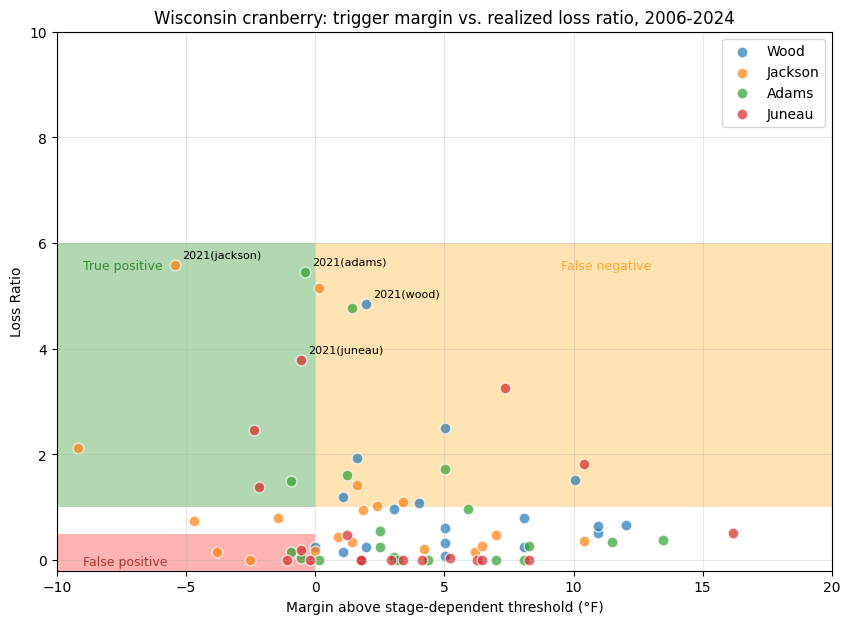

In [52]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 7))

# Set rectangles
ax.set_xlim(-10, 20)
ax.set_ylim(-0.2, 10)

# True positive: triggered and real loss (LR > 1.0)
ax.add_patch(Rectangle((-10, 1.0), 10, 5, facecolor = "green", alpha = 0.3, zorder = 0))
ax.text(-9, 5.5, "True positive", fontsize = 9, color = "darkgreen", alpha = 0.7)
# False positive: triggered but no real loss (LR < 0.5)
ax.add_patch(Rectangle((-10, -0.2), 10, 0.7, facecolor = "red", alpha = 0.3, zorder = 0))
ax.text(-9, -0.1, "False positive", fontsize = 9, color = "darkred", alpha = 0.7)
# False negative: not triggered but real loss (LR > 1.0)
ax.add_patch(Rectangle((0,1.0), 20, 5, facecolor = "orange", alpha = 0.3, zorder = 0))
ax.text(13, 5.5, "False negative", fontsize = 9, color = "darkorange", alpha = 0.7, horizontalalignment="right")


# Plot data
colors = {"wood": "C0","jackson": "C1","adams": "C2","juneau": "C3"}
for name, df in counties.items():
    ax.scatter(df["margin"],df["Loss Ratio"],
              label=name.capitalize(), color=colors[name],s=60,alpha=0.7, edgecolor="white")

ax.set_xlabel("Margin above stage-dependent threshold (°F)")
ax.set_ylabel("Loss Ratio")
ax.set_title("Wisconsin cranberry: trigger margin vs. realized loss ratio, 2006-2024")
ax.legend()
ax.grid(alpha=0.3)


for name, df in counties.items():
    row_2021 = df[df["year"] == 2021].iloc[0]
    ax.annotate(f"2021({name})", xy=(row_2021["margin"],row_2021["Loss Ratio"]), xytext=(5,5), textcoords="offset points", fontsize = 8)

plt.show()
            

In [45]:
counties

{'wood':     year  tmin_f  threshold  margin  Policies Sold  Policies Indemnified  \
 0   2011   24.98       25.0   -0.02             63                     5   
 1   2013   26.06       25.0    1.06             67                     4   
 2   2020   26.06       25.0    1.06             69                    13   
 3   2010    26.6       25.0     1.6             62                    14   
 4   2016   26.96       25.0    1.96             65                     3   
 5   2021   26.96       25.0    1.96             68                    31   
 6   2017   28.04       25.0    3.04             70                     8   
 7   2006   28.04       25.0    3.04             59                     1   
 8   2015   30.02       26.0    4.02             65                    10   
 9   2014   30.02       25.0    5.02             63                     6   
 10  2008   30.02       25.0    5.02             61                     2   
 11  2022   30.02       25.0    5.02             69                 

# Cause of Loss Data

Now we will pull cause of loss data from these Wisconsin counties of interest for 2006 - 2024

**Field Code Definitions**

RMA Cause of Loss files are pipe-delimeted with the following Element Name/Format/Description:

1 Commodity Year Identifier <br>
9(04) <br>
The identifier that represents the year in which the crop/commodity is normally harvested and indicates the policy year for which coverage was provided.

2 State Code <br>
9(02) <br>
The FIPS code that denotes the State in which the insured farm is located.

3 State Abbreviation <br>
X(02) <br>
USPS state abbreviation

4 County Code <br>
9(03) <br>
The FIPS code that denotes the County in which the insured farm is located.

5 County Name <br>
X(30) <br>
Name of the county.

6 Commodity Code <br>
9(04) <br>
The Risk Management Agency (RMA) code that denotes the crop/commodity for which the policy is issued.

7 Commodity Name <br>
X(30) <br>
Name of the crop/commodity

8 Insurance Plan Code <br>
9(02) <br>
Code that denotes the type of insurance coverage is selected for theinsured crop (e.g.APH, Revenue, Dollar, etc.)

9 Insurance Plan Name Abbreviation <br>
X(05) <br>
Abbreviation of the Insurance Plan Name

10 Coverage Category <br>
X(01) <br>
Code that identifies the category of coverage elected :<br>
 A = Buyup ; C = CAT ; E = Existing Coverage Policy ;<br>
 L = Limited Coverage

11 Stage Code <br>
X(02) See Stage Code Listing

12 Cause of Loss Code <br>
9(02) <br>
The RMA code that identifies the peril that caused the loss on the crop

13 Cause of Loss Description <br>
X(35) <br>
Description of the cause of loss.

14 Month of Loss <br>
9(02) <br>
Month when the loss occurred

15 Month of Loss Name <br>
X(03) <br>
Name of the month when the loss occurred

16 Year of Loss <br>
9(04) <br>
Year the loss occurred

17 Policies Earning Premium <br>
9(09) <br>
Count of the number of crop policies with premium NOTE : Not available for years prior to 1989.

18 Policies Indemnified <br>
9(09) <br>
Count of the number of crop policies with a reported loss

19 Net Planted Quantity <br>
9(12)V9(02) <br>
Number of acres, tons, pounds, etc. planted to the crop after the insured’s share is applied.

20 Net Endorsed Acres <br>
9(12)V9(02) <br>
Number of acres insured under an endorsement (e.g. SCO, STAX, Margin Protection)

21 Liability <br>
9(12) <br>
The maximum dollar amount of insurance for the crop

22 Total Premium <br>
9(12) <br>
Premium before application of any subsidies. In general, the base premium rates times liability (Also called the base premium)

23 Producer Paid Premium <br>
9(12) <br>
Premium paid by the producer

24 Subsidy <br>
9(12) <br>
Amount of subsidized premium.

25 State/Private Subsidy <br>
9(12) <br>
Subsidy provided by a state or private entity

26 Additional Subsidy <br>
9(12) <br>
An additional subsidy from a program or other process. 2021 and 2022 Additional Subsidy represents Pandemic Cover Crop Program amount.

27 EFA Premium Discount <br>
9(12)

28 Net Determined Quantity <br>
9(12)V9(02) <br>
Number of acres, tons, pounds, etc. loss due to damage after the insured’s share is applied

29 Indemnity Amount <br>
S9(12) <br>
The total amount of the loss for the designated peril.

30 Loss Ratio <br>
9(5)V9(02) <br>
Calculated: Indemnity / Total Premium. 

Note: WI state code is 55. Cranberry commodity code is 0058

**2024 Data** <br>
Here, we pull cause of loss data for cranberries in WI in 2024 as a test to see how the data is displayed.

In [74]:
test = pd.read_csv("data/colsom_2024.txt", sep = "|", header = None)
test.columns=["year", "statecode", "state", "countycode", "county", "commoditycode", "commodity", "col8", "col9", "col10", "col11", "causeoflosscode", "causeoflossdesc", "month", "monthname", "yearloss", "policiespremium", "policiesindemnified", "col19", "col20", "col21", "TotalPremium", "col23", "col24", "col25", "col26", "col27", "col28", "IndemnityAmt", "col30", ]

WI = 55
CRAN = 58
wi_cran = test[(test["statecode"]==WI)&(test["commoditycode"]==CRAN)]
print(wi_cran.shape)
print(wi_cran["county"].value_counts())
print(wi_cran["causeoflossdesc"].value_counts())

(30, 30)
county
Wood                              9
Monroe                            7
Portage                           6
Adams                             3
Juneau                            3
Jackson                           2
Name: count, dtype: int64
causeoflossdesc
Hail                                  11
Cold Wet Weather                       9
Excess Moisture/Precipitation/Rain     3
Cold Winter                            3
Drought                                1
Heat                                   1
Frost                                  1
All Other Causes                       1
Name: count, dtype: int64


Note here: Portage county has some cranberry crop that previously I did not notice. **Note this for later**

**2021 Data** <br>
Before pulling all data together and making larger inferences, I want to pull data from 2021 which was a year identified by high loss ratios and indemnities in all four previously explored counties from the LR data.

In [73]:
test21 = pd.read_csv("data/colsom_2021.txt", sep = "|", header = None)
test21.columns=["year", "statecode", "state", "countycode", "county", "commoditycode", "commodity", "col8", "col9", "col10", "col11", "causeoflosscode", "causeoflossdesc", "month", "monthname", "yearloss", "policiespremium", "policiesindemnified", "col19", "col20", "col21", "TotalPremium", "col23", "col24", "col25", "col26", "col27", "col28", "IndemnityAmt", "col30", ]

WI = 55
CRAN = 58
wi_cran21 = test21[(test21["statecode"]==WI)&(test21["commoditycode"]==CRAN)]
print(wi_cran21.shape)
print(wi_cran21["county"].value_counts())
print(wi_cran21["causeoflossdesc"].value_counts())

(89, 30)
county
Wood                              25
Monroe                            15
Portage                           15
Jackson                           14
Juneau                            10
Adams                              9
Sawyer                             1
Name: count, dtype: int64
causeoflossdesc
Excess Moisture/Precipitation/Rain    20
Cold Wet Weather                      16
Frost                                 11
Freeze                                11
Heat                                   9
Other (Snow, Lightning, Etc.)          9
Hail                                   7
All Other Causes                       6
Name: count, dtype: int64


What do we see from this data pull? <br>
<br>
7 counties affected by cranberry losses
<br> <br>
Cause of loss breakdown:
- Frost & Freeze combine to 22 losses - highest driver. Confirms prior hypothesis that frost/freeze was a primary driver of 2021 losses, accounting for about 25% of all loss records. Compare this with 2024, a year with only 1 frost loss. Shows 2021 is an outlier.
- Excess Moisture/Precipitation/Rain caused 20 losses. Not a related cause of loss to the current research, but important to note where other casues come into play.
- Cold Wet Weather causes 16 losses. This is a related but distinct cause, likely not captured by the temperature triggers because it would lie right above the thresholds (think cold rain around 32 or 33 degrees). The current product positioning likely covers Frost+Freeze damage, not this cold wet weather cause. 

# To Do
- Load all years of data for cause of loss in this way
- Verify definitions of Frost vs. Freeze vs. Cold Wet Weather codes from RMA. Determine if we want to include Cold Wet Weather
- Track Frost + Freeze cause of loss amounts over time. Compare high years with the temperature trigger years to see if volume of losses correlate
- This is better idea. Track Frost + Freeze Indemnity amounts (column 29) in the same way, tracking loss severity against the temperature trigger years. This will give more accurate LR information (column 30 - maybe manually solve LR?) than the prior LRs we explored because we can dive down into just the frost+freeze losses rather than all losses for any given year.

## Future: Rework validation using frost+freeze-specific losses

Rebuild the four-county validation analysis using only frost+freeze indemnities (not total indemnities):

- Recompute "loss ratio" as frost+freeze indemnity / total premium for each county-year
- Regenerate the margin vs. LR scatter plot using frost-specific LR
- Rebuild the cross-county comparison tables
- Reassess which years were true positives, false positives, false negatives under the cleaner signal
- Compare frost-specific results to the original total-LR results — does the trigger look better, worse, or similar?
- Decide whether to include "Cold Wet Weather" in the frost peril definition

This is the methodological upgrade that turns the validation from "trigger catches bad insurance years" to "trigger catches actual frost loss years" — a more honest test of the product hypothesis.

Target: August, after MAS-I.